In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")

print("Path to dataset files:", path)

100%|██████████| 19.8M/19.8M [00:00<00:00, 173MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1


In [17]:
import os

# Show files inside the downloaded folder
files = os.listdir(path)

print("Files in dataset folder:")
for file in files:
    print(file)

Files in dataset folder:
complaints_processed.csv


In [18]:
import pandas as pd
import os

# Find CSV files
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

print("CSV files found:", csv_files)

# Load the first CSV file
file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

CSV files found: ['complaints_processed.csv']
Dataset loaded successfully!


In [19]:
# Display number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 162421
Number of columns: 3


In [20]:
# Display column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Unnamed: 0', 'product', 'narrative']


In [21]:
# Display first 5 rows
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [22]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB


In [23]:
# Check missing values
print(df.isnull().sum())

Unnamed: 0     0
product        0
narrative     10
dtype: int64


In [24]:
# Remove rows with missing complaint text or category
df = df.dropna(subset=["narrative", "product"])

print("Rows after removing missing values:", len(df))

Rows after removing missing values: 162411


In [25]:
# Display all complaint categories
print(df["product"].unique())

['credit_card' 'retail_banking' 'credit_reporting' 'mortgages_and_loans'
 'debt_collection']


In [26]:
# Count complaints in each category
category_counts = df["product"].value_counts()

print(category_counts)

product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


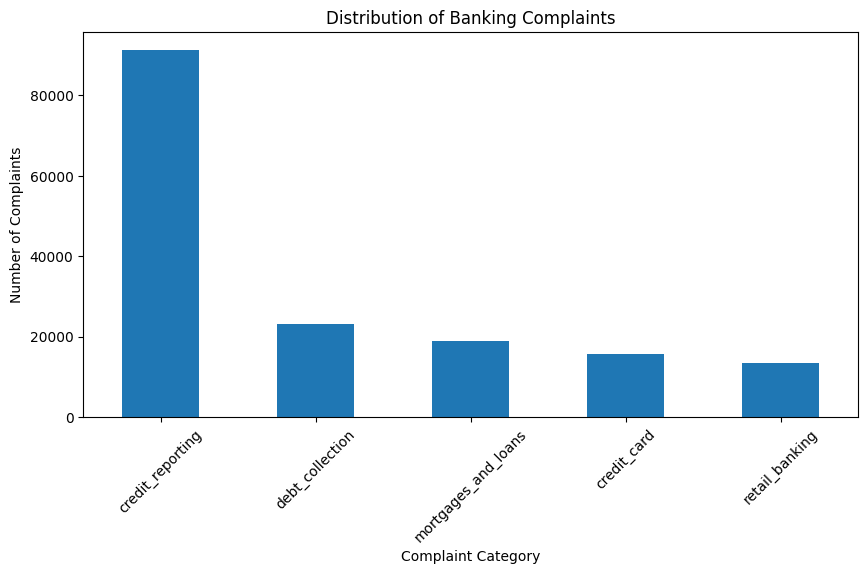

In [27]:
import matplotlib.pyplot as plt

# Create category chart
plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.title("Distribution of Banking Complaints")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

In [28]:
# Display sample complaints
df[["product", "narrative"]].head(10)

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
5,credit_reporting,payment history missing credit report made mis...
6,credit_reporting,va date complaint experian credit bureau invol...
7,credit_reporting,account reported abbreviated name full name se...
8,credit_reporting,account reported abbreviated name full name se...
9,credit_reporting,usdoexxxx account reported abbreviated name fu...


In [29]:
print("Category:")
print(df["product"].iloc[0])

print("\nComplaint:")
print(df["narrative"].iloc[0])

Category:
credit_card

Complaint:
purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issu

In [30]:
import re
import nltk

# Download English stopwords
nltk.download("stopwords")

from nltk.corpus import stopwords

# Get English stopwords
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
# Function to clean complaint text
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Join words
    return " ".join(words)

In [33]:
# Clean complaint text
df["clean_narrative"] = df["narrative"].apply(clean_text)

# Display original and cleaned text
df[["narrative", "clean_narrative"]].head()

,narrative,clean_narrative
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


In [34]:
# Calculate number of words in each complaint
df["text_length"] = df["clean_narrative"].apply(lambda x: len(x.split()))

# Display statistics
print(df["text_length"].describe())

count    162411.000000
mean         80.207935
std         108.821314
min           1.000000
25%          27.000000
50%          50.000000
75%          95.000000
max        2684.000000
Name: text_length, dtype: float64


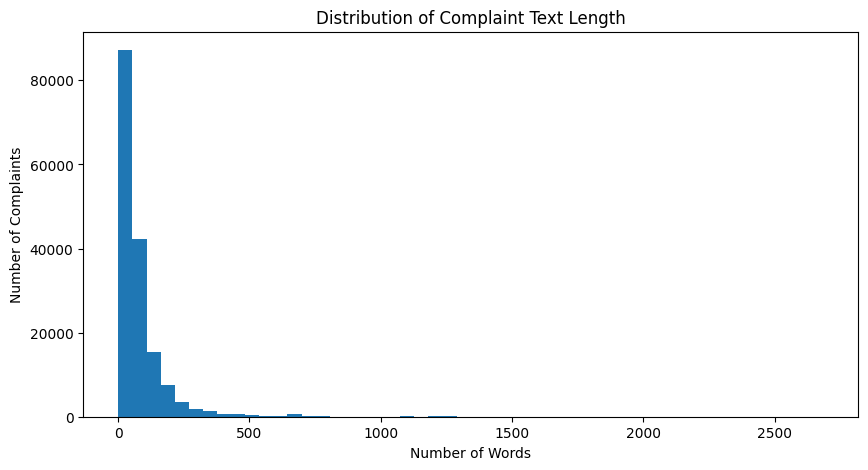

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Complaint Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Complaints")

plt.show()

In [36]:
from collections import Counter

# Combine all cleaned complaints
all_text = " ".join(df["clean_narrative"])

# Split into words
words = all_text.split()

# Count words
word_counts = Counter(words)

# Display top 20 words
print("Most common words:")
print(word_counts.most_common(20))

Most common words:
[('credit', 317561), ('account', 316151), ('report', 177193), ('information', 143538), ('payment', 127704), ('reporting', 94522), ('time', 82905), ('company', 79449), ('would', 78230), ('day', 77044), ('loan', 75353), ('debt', 74785), ('received', 71590), ('card', 70288), ('letter', 70005), ('bank', 67169), ('consumer', 64075), ('dispute', 60232), ('sent', 59366), ('never', 58350)]


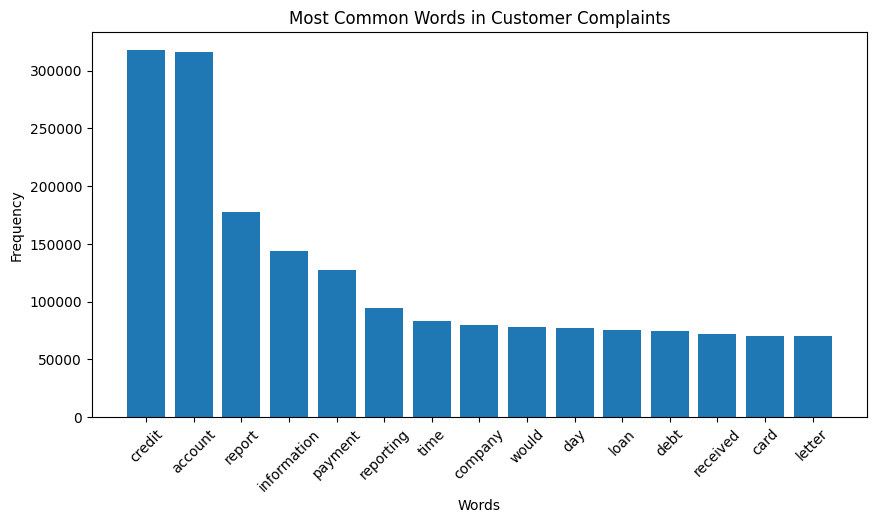

In [37]:
# Get top 15 words
top_words = word_counts.most_common(15)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

# Create bar chart
plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.title("Most Common Words in Customer Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [38]:
# Input data
X = df["clean_narrative"]

# Target category
y = df["product"]

print("Input size:", X.shape)
print("Target size:", y.shape)

Input size: (162411,)
Target size: (162411,)


In [39]:
from sklearn.model_selection import train_test_split

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 129928
Testing records: 32483


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert training text
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert testing text
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (129928, 5000)
Testing TF-IDF shape: (32483, 5000)


In [41]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(
    max_iter=1000
)

# Train model
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [42]:
# Predict categories
y_pred = model.predict(X_test_tfidf)

# Display some predictions
for actual, predicted in zip(y_test.head(10), y_pred[:10]):

    print("Actual   :", actual)
    print("Predicted:", predicted)
    print()

Actual   : debt_collection
Predicted: debt_collection

Actual   : credit_card
Predicted: credit_card

Actual   : debt_collection
Predicted: debt_collection

Actual   : credit_card
Predicted: credit_card

Actual   : credit_reporting
Predicted: credit_reporting

Actual   : credit_reporting
Predicted: credit_reporting

Actual   : debt_collection
Predicted: debt_collection

Actual   : retail_banking
Predicted: retail_banking

Actual   : credit_reporting
Predicted: credit_reporting

Actual   : credit_reporting
Predicted: mortgages_and_loans



In [43]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 87.6 %


In [44]:
from sklearn.metrics import classification_report

# Display classification report
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      3113
   credit_reporting       0.91      0.94      0.92     18235
    debt_collection       0.81      0.73      0.77      4630
mortgages_and_loans       0.86      0.83      0.84      3798
     retail_banking       0.86      0.89      0.88      2707

           accuracy                           0.88     32483
          macro avg       0.85      0.83      0.84     32483
       weighted avg       0.87      0.88      0.87     32483



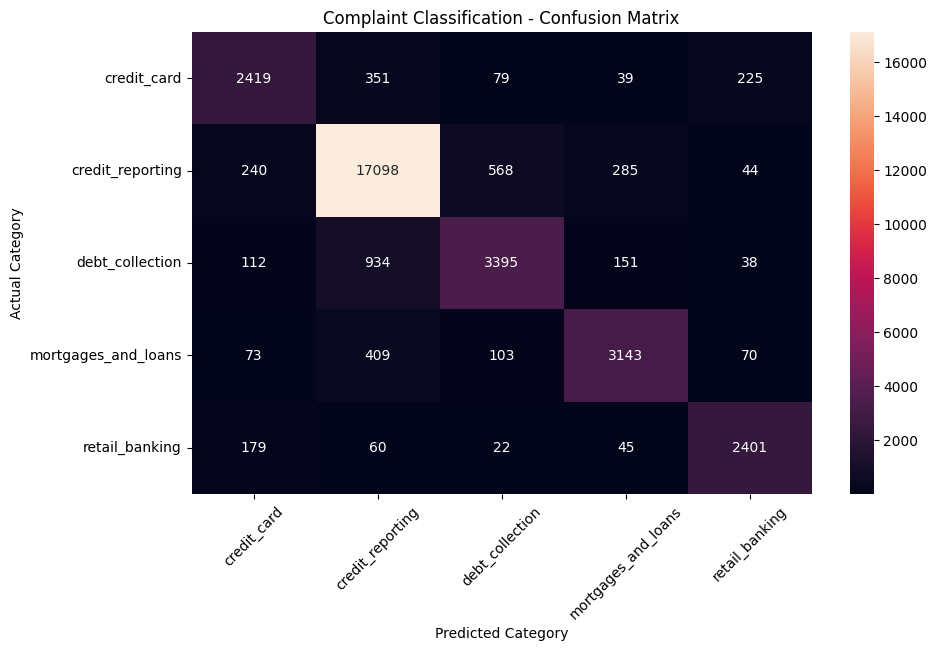

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Complaint Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [46]:
# Count complaints by category
issue_counts = df["product"].value_counts()

print("Frequent Banking Issues:")
print(issue_counts)

Frequent Banking Issues:
product
credit_reporting       91172
debt_collection        23148
mortgages_and_loans    18990
credit_card            15566
retail_banking         13535
Name: count, dtype: int64


In [47]:
# Calculate complaint percentages
issue_percentage = df["product"].value_counts(normalize=True) * 100

print(issue_percentage.round(2))

product
credit_reporting       56.14
debt_collection        14.25
mortgages_and_loans    11.69
credit_card             9.58
retail_banking          8.33
Name: proportion, dtype: float64


In [48]:
# Find common words for each complaint category

for category in df["product"].unique():

    # Select complaints from this category
    category_data = df[df["product"] == category]

    # Combine text
    category_text = " ".join(category_data["clean_narrative"])

    # Count words
    category_words = Counter(category_text.split())

    print("\n" + "=" * 50)
    print("Category:", category)
    print("=" * 50)

    print(category_words.most_common(10))


Category: credit_card
[('card', 37861), ('credit', 33268), ('account', 28506), ('payment', 17876), ('bank', 14078), ('charge', 13869), ('would', 13002), ('time', 12595), ('one', 11316), ('received', 10273)]

Category: retail_banking
[('account', 45472), ('bank', 26096), ('money', 15977), ('would', 10500), ('day', 9942), ('told', 9681), ('check', 9313), ('fund', 9162), ('time', 8675), ('transaction', 8135)]

Category: credit_reporting
[('credit', 224547), ('account', 188590), ('report', 144587), ('information', 107572), ('reporting', 80306), ('consumer', 50212), ('payment', 45660), ('dispute', 42434), ('letter', 39075), ('day', 39048)]

Category: mortgages_and_loans
[('payment', 47361), ('loan', 44211), ('mortgage', 26602), ('would', 22593), ('account', 19100), ('time', 18356), ('credit', 15874), ('told', 15638), ('company', 14550), ('received', 14327)]

Category: debt_collection
[('debt', 42663), ('credit', 39201), ('account', 34483), ('collection', 22212), ('report', 20639), ('compan

In [49]:
# New customer complaint
new_complaint = [
    "I was charged a fee on my credit card and I do not understand why"
]

# Clean the complaint
clean_complaint = [clean_text(new_complaint[0])]

# Convert to TF-IDF
new_tfidf = tfidf.transform(clean_complaint)

# Predict category
prediction = model.predict(new_tfidf)

print("Customer Complaint:")
print(new_complaint[0])

print("\nPredicted Category:")
print(prediction[0])

Customer Complaint:
I was charged a fee on my credit card and I do not understand why

Predicted Category:
credit_card


In [50]:
# Improvement suggestions

suggestions = {

    "Credit reporting":
    "Improve credit report accuracy, dispute handling, and customer communication.",

    "Debt collection":
    "Provide clearer information about outstanding debts, payment options, and collection procedures.",

    "Mortgages and loans":
    "Improve transparency about loan terms, interest rates, approval processes, and repayment schedules.",

    "Credit cards":
    "Improve communication about fees, transactions, payments, interest, and disputed charges.",

    "Retail banking":
    "Improve account services, transaction support, online banking, and response time."
}

# Display suggestions
for category, suggestion in suggestions.items():

    print("\nCategory:", category)
    print("Suggestion:", suggestion)


Category: Credit reporting
Suggestion: Improve credit report accuracy, dispute handling, and customer communication.

Category: Debt collection
Suggestion: Provide clearer information about outstanding debts, payment options, and collection procedures.

Category: Mortgages and loans
Suggestion: Improve transparency about loan terms, interest rates, approval processes, and repayment schedules.

Category: Credit cards
Suggestion: Improve communication about fees, transactions, payments, interest, and disputed charges.

Category: Retail banking
Suggestion: Improve account services, transaction support, online banking, and response time.
